In [ ]:
import numpy as np

data = np.load("/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_test_normal.npz")

print(data.files)

In [ ]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

scan_ids = data["scan_ids"]

unique_scans = np.unique(scan_ids)

print("Number of unique scans:", len(unique_scans))

for s in unique_scans:
    print(s)

In [ ]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

scan_ids = data["scan_ids"]

unique_scans, counts = np.unique(
    scan_ids,
    return_counts=True
)

# Sort by least number of patches
least_idx = np.argsort(counts)

print("Scans with the fewest patches:\n")

for i in least_idx[:20]:   # show 20 least frequent scans
    print(f"{unique_scans[i]} : {counts[i]} patches")

# Zero Norms

In [ ]:
X = data["X"]

print("Patch matrix shape:", X.shape)

# Each column = one patch
patch_norms = np.linalg.norm(X, axis=0)

zero_mask = patch_norms < 1e-10


print("\n===== Patch Norm Statistics =====")
print("Total patches:", X.shape[1])
print("Zero norm patches:", zero_mask.sum())

print(
    f"Percentage zero norm patches: "
    f"{zero_mask.sum()/X.shape[1]*100:.6f}%"
)


print("\nNorm statistics")
print("Min norm:", patch_norms.min())
print("Max norm:", patch_norms.max())
print("Mean norm:", patch_norms.mean())
print("Median norm:", np.median(patch_norms))

In [ ]:
import numpy as np

patch_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train.npz"

data = np.load(
    patch_path,
    allow_pickle=True
)

X = data["X"]
scan_ids = data["scan_ids"]

# Compute norms
patch_norms = np.linalg.norm(X, axis=0)

# Find zero norm patches
zero_mask = patch_norms < 1e-10

# Get scan IDs corresponding to zero norm patches
zero_norm_scan_ids = scan_ids[zero_mask]


print("Number of zero norm patches:", len(zero_norm_scan_ids))

print("\nFirst 20 zero norm patch scan IDs:")
print(zero_norm_scan_ids[:20])

In [ ]:
unique_zero_scan_ids, counts = np.unique(
    zero_norm_scan_ids,
    return_counts=True
)

print("Number of scans containing zero-norm patches:",
      len(unique_zero_scan_ids))

for scan_id, count in zip(unique_zero_scan_ids, counts):
    print(scan_id, "->", count, "zero-norm patches")

# Train Normal Patches

In [ ]:
import numpy as np

data = np.load("/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_normal.npz", allow_pickle=True)

X = data["X"]

print("Shape:", X.shape)

print("NaN:", np.isnan(X).sum())
print("Inf:", np.isinf(X).sum())

print("Min:", X.min())
print("Max:", X.max())

In [ ]:
import numpy as np

path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_balanced.npz"

data = np.load(path, allow_pickle=True)

X = data["X"]
H = data["H"]
scan_ids = data["scan_ids"]


print("==============================")
print("Dataset shapes")

print("X:", X.shape)
print("H:", H.shape)
print("scan_ids:", scan_ids.shape)



print("\n==============================")
print("Class distribution")

classes, counts = np.unique(H, return_counts=True)

for c, n in zip(classes, counts):
    print(f"Class {c}: {n}")



print("\n==============================")
print("Unique CT scans")

unique_scans = np.unique(scan_ids)

print("Number of scans:", len(unique_scans))


print("\nFirst 10 scan IDs:")
for s in unique_scans[:10]:
    print(s)



print("\n==============================")
print("Patches per scan statistics")

patches_per_scan = []

for sid in unique_scans:
    patches_per_scan.append(
        np.sum(scan_ids == sid)
    )


patches_per_scan = np.array(patches_per_scan)


print("Min patches:", patches_per_scan.min())
print("Max patches:", patches_per_scan.max())
print("Mean patches:", patches_per_scan.mean())
print("Median patches:", np.median(patches_per_scan))



print("\n==============================")
print("Check alignment")

print(
    "X patches == labels:",
    X.shape[1] == len(H)
)

print(
    "Labels == scan ids:",
    len(H) == len(scan_ids)
)

# Find patch indices

In [ ]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

X = data["X"]
scan_ids = data["scan_ids"]
coords = data["coords"]
H = data["H"]

target_scan = "train_11150_b_2"

# Find patch indices
indices = np.where(scan_ids == target_scan)[0]

print("Number of patches:", len(indices))
print("Patch matrix column indices:")
print(indices)

In [ ]:
coords = data["coords"]
scan_ids = data["scan_ids"]
scan_id = "train_11150_b_2"
indices = np.where(
    scan_ids == scan_id
)[0]

print("Indices:")
print(indices)

print("\nCoordinates:")
print(coords[indices])

# Visualize Patch Matrix

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from lc_ksvd.data_loader.metadata_registry import MetadataRegistry
from lc_ksvd.data_loader.scan_loader import ScanLoader
from lc_ksvd.config import PATCH_SIZE, CLASS_ORDER

target_scan = "train_11150_b_2"
split = "train"   # matches the "train_" prefix / patch file split

# --- Load the actual preprocessed volume + resampled ground-truth mask ---
metadata = MetadataRegistry(split=split)
scan = ScanLoader(metadata).load(target_scan)

volume = scan["volume"]          # float32 [H, W, D] in [0, 1], resampled/windowed
mask = scan["mask"]              # uint8 [F, H, W, D] or None, same grid as volume
finding_map = scan["finding_map"]  # {f_idx: category}, e.g. {0: "2c"}

print("Volume shape:", volume.shape)
print("Finding map:", finding_map)

# --- Patch coords for this scan (already in the same coordinate space as volume) ---
patch_data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True,
)
scan_ids = patch_data["scan_ids"]
coords = patch_data["coords"]

indices = np.where(scan_ids == target_scan)[0]
scan_coords = coords[indices]

# --- Collapse ground truth mask (any finding) into a single binary volume ---
gt = None
if mask is not None:
    gt = mask.any(axis=0)  # [H, W, D] bool, union over all findings

# --- Pick a slice to visualize: center of the patch cloud along z ---
if len(scan_coords) > 0:
    cz = int(np.median(scan_coords[:, 2] + PATCH_SIZE // 2))
else:
    cz = volume.shape[2] // 2

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(volume[:, :, cz], cmap="gray")

# Overlay ground truth mask (red, semi-transparent)
if gt is not None:
    gt_slice = gt[:, :, cz]
    overlay = np.zeros((*gt_slice.shape, 4))
    overlay[gt_slice] = [1, 0, 0, 0.4]  # red, alpha 0.4
    ax.imshow(overlay)

# Overlay patch boxes that intersect this slice
for (x0, y0, z0) in scan_coords:
    if z0 <= cz < z0 + PATCH_SIZE:
        rect = mpatches.Rectangle(
            (y0, x0), PATCH_SIZE, PATCH_SIZE,
            linewidth=1, edgecolor="lime", facecolor="none",
        )
        ax.add_patch(rect)

ax.set_title(f"{target_scan} — slice z={cz} (green=patches, red=GT)")
ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(volume.flatten(), bins=100)
plt.xlabel("Reconstructed intensity")
plt.ylabel("Voxel count")
plt.title("Reconstructed Volume Histogram")
plt.show()

print("min:", volume.min())
print("max:", volume.max())
print("mean:", volume.mean())
print("std:", volume.std())

In [ ]:
# choose threshold
threshold = np.percentile(volume[volume != 0], 50)
print("Threshold:", threshold)

segmentation = volume > threshold
print("Foreground voxels:", segmentation.sum())

In [ ]:
cx, cy, cz = np.array(segmentation.shape)//2

fig, ax = plt.subplots(1,3,figsize=(12,4))

ax[0].imshow(segmentation[:,:,cz], cmap="gray")
ax[0].set_title("Axial")

ax[1].imshow(segmentation[:,cy,:], cmap="gray")
ax[1].set_title("Coronal")

ax[2].imshow(segmentation[cx,:,:], cmap="gray")
ax[2].set_title("Sagittal")

for a in ax:
    a.axis("off")

plt.show()

## Otsu threshold

In [ ]:
from skimage.filters import threshold_otsu

nonzero = volume[volume != 0]

threshold = threshold_otsu(nonzero)
print("Otsu threshold:", threshold)

segmentation = volume > threshold

In [ ]:
from scipy.ndimage import binary_opening, binary_closing, label
from scipy.ndimage import label

segmentation = binary_opening(
    segmentation,
    iterations=1
)

segmentation = binary_closing(
    segmentation,
    iterations=2
)

labeled, num = label(segmentation)

sizes = np.bincount(labeled.ravel())

# remove background
sizes[0] = 0

largest_component = sizes.argmax()

segmentation = labeled == largest_component

print(
    "Final segmentation voxels:",
    segmentation.sum()
)

In [ ]:
cx,cy,cz = np.array(volume.shape)//2

fig,ax = plt.subplots(1,3,figsize=(12,4))

ax[0].imshow(volume[:,:,cz], cmap="gray")
ax[0].contour(segmentation[:,:,cz], colors="red")
ax[0].set_title("Axial")

ax[1].imshow(volume[:,cy,:], cmap="gray")
ax[1].contour(segmentation[:,cy,:], colors="red")
ax[1].set_title("Coronal")

ax[2].imshow(volume[cx,:,:], cmap="gray")
ax[2].contour(segmentation[cx,:,:], colors="red")
ax[2].set_title("Sagittal")

for a in ax:
    a.axis("off")

plt.show()

In [ ]:
import nibabel as nib
import os

# Convert boolean mask to uint8
segmentation_uint8 = segmentation.astype(np.uint16)

# Save path
save_path = f"/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/reconstructed/{scan_id}.nii.gz"

# Create identity affine (because this is a cropped reconstruction)
affine = np.eye(4)

# Create NIfTI image
nii = nib.Nifti1Image(
    segmentation_uint8,
    affine
)

# Save
nib.save(
    nii,
    save_path
)

print("Saved segmentation:")
print(save_path)

print("Shape:", segmentation_uint8.shape)
print("Foreground voxels:", segmentation_uint8.sum())

In [8]:
import pandas as pd

patch_df = pd.read_csv(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/lcksvd2_svm_test_20260731_101314/patch_level.csv"
)

scan_acc = (
    patch_df.groupby("scan_id")
    .agg(
        true_class=("true_class", "first"),
        n_patches=("correct", "size"),
        n_correct=("correct", "sum"),
    )
    .assign(accuracy=lambda d: d["n_correct"] / d["n_patches"])
    .reset_index()
    .sort_values("accuracy", ascending=False)
)

top_n = 40
top_scans = scan_acc.head(top_n)
print(top_scans)

# patches belonging to the top scans, if you want to inspect them directly
top_patches = patch_df[patch_df["scan_id"].isin(top_scans["scan_id"])]
top_patches


            scan_id true_class  n_patches  n_correct  accuracy
37    valid_457_d_2         2d          6          6  1.000000
13  train_18107_a_2     normal        858        805  0.938228
11  train_17370_a_1     normal        762        711  0.933071
25   train_6321_b_2     normal       1029        948  0.921283
39    valid_902_a_2         2d       1113       1016  0.912848
23   train_5864_b_1     normal        609        552  0.906404
7   train_15829_a_1     normal        392        354  0.903061
32    valid_102_a_2         2d        154        139  0.902597
27   train_8143_a_1     normal        587        529  0.901193
16   train_2510_a_1     normal        746        669  0.896783
18   train_3994_a_1     normal        870        780  0.896552
12  train_17896_b_2     normal        510        453  0.888235
2   train_12132_a_2     normal        788        699  0.887056
8   train_16003_a_2     normal       1292       1142  0.883901
36    valid_342_a_2         2c        102         90  0

,scan_id,true_label,pred_label,true_class,pred_class,correct
0,train_16110_a_1,0,0,normal,normal,True
1,train_16110_a_1,0,0,normal,normal,True
2,train_16110_a_1,0,0,normal,normal,True
3,train_16110_a_1,0,2,normal,2d,False
4,train_16110_a_1,0,0,normal,normal,True
...,...,...,...,...,...,...
28747,valid_1016_d_1,2,0,2d,normal,False
28748,valid_1016_d_1,2,2,2d,2d,True
28749,valid_1016_d_1,2,0,2d,normal,False
28750,valid_1016_d_1,2,1,2d,2c,False


In [1]:
import json
from pathlib import Path

DATASET_2_LAST = Path("/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last.json")
OUT_PATH = Path("/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last_top_test.json")

# the scan_ids to keep (from the patch-level accuracy ranking above)
keep_scan_ids = set(scan_acc["scan_id"])  # or top_scans["scan_id"] for just the top-N

with open(DATASET_2_LAST) as f:
    dataset = json.load(f)

filtered_test = [
    entry for entry in dataset["test"]
    if Path(entry["name"]).stem.replace(".nii", "") in keep_scan_ids
]

missing = keep_scan_ids - {Path(e["name"]).stem.replace(".nii", "") for e in filtered_test}
assert not missing, f"scan_ids not found in dataset_2_last test set: {missing}"

new_dataset = {
    "train": dataset["train"],   # unchanged
    "test": filtered_test,        # only the kept scans, metadata untouched
}

with open(OUT_PATH, "w") as f:
    json.dump(new_dataset, f, indent=2)

print(f"Kept {len(filtered_test)}/{len(dataset['test'])} test scans -> {OUT_PATH}")


NameError: name 'scan_acc' is not defined

In [9]:
import json
import numpy as np

# Load patch matrix scan ids
patches = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_shuffled.npz",
    allow_pickle=True,
)
patch_scan_ids = set(patches["scan_ids"])  # e.g. "train_122_b_1" (no .nii.gz)

# Load json dataset (train split, since patches file is "unified_train_shuffled")
with open("/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last.json") as f:
    dataset = json.load(f)

json_names = {entry["name"].removesuffix(".nii.gz") for entry in dataset["train"]}

missing_from_patches = sorted(json_names - patch_scan_ids)
extra_in_patches = sorted(patch_scan_ids - json_names)

print(f"JSON train scans: {len(json_names)}")
print(f"Unique scans in patch matrix: {len(patch_scan_ids)}")
print(f"In JSON but missing from patches: {len(missing_from_patches)}")
print(f"In patches but not in JSON: {len(extra_in_patches)}")

missing_from_patches[:20]


JSON train scans: 1314
Unique scans in patch matrix: 239
In JSON but missing from patches: 1075
In patches but not in JSON: 0


['train_10000_a_1',
 'train_10006_b_2',
 'train_10017_a_2',
 'train_10083_a_2',
 'train_10083_b_2',
 'train_10083_c_2',
 'train_1008_a_2',
 'train_10094_a_2',
 'train_10094_c_1',
 'train_10104_a_1',
 'train_10106_a_2',
 'train_1015_a_1',
 'train_10165_a_1',
 'train_10177_a_2',
 'train_10180_a_2',
 'train_1018_a_2',
 'train_10198_a_2',
 'train_10198_b_2',
 'train_10216_a_1',
 'train_10243_a_1']

In [10]:
print("Patch scan ids:")
print(list(patch_scan_ids)[:10])

print("\nJSON scan ids:")
print(list(json_names)[:10])

Patch scan ids:
['train_10990_a_1', 'train_19167_a_1', 'train_14964_a_2', 'train_13189_a_1', 'train_2002_a_2', 'train_17322_b_2', 'train_1540_a_1', 'train_6629_a_1', 'train_2965_b_2', 'train_8188_a_2']

JSON scan ids:
['train_19167_a_1', 'valid_915_c_2', 'valid_610_a_1', 'train_7442_a_1', 'train_5632_a_1', 'train_2403_a_1', 'train_1292_b_2', 'train_1959_b_2', 'train_11054_a_2', 'train_8044_a_1']


In [11]:
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ---------- your paths ----------
volume_path = r"D:\My\Projects\fyp-3d-ct\data_volumes\dataset\train\train_1387\train_1387_a\train_1387_a_2.nii.gz"
mask_path   = r"D:\My\Projects\fyp-3d-ct\data\segmentations\train_1387_a_2.nii.gz"
DATASET_JSON = r"D:\My\Projects\fyp-3d-ct\data\rexgrounding-ct\dataset_2.json"

# ---------- load metadata ----------
with open(DATASET_JSON) as f:
    meta = json.load(f)

# find this sample in any split
entry = None
for split in meta:
    for e in meta[split]:
        if e["name"] == "train_1387_a_2.nii.gz":
            entry = e
            break
    if entry:
        break

if entry is None:
    raise ValueError("train_1387_a_2.nii.gz not found in JSON")

cats  = entry["categories"]
finds = entry.get("findings", {})

# ---------- load volume & mask ----------
ct   = nib.load(volume_path).get_fdata()
mask = nib.load(mask_path).get_fdata()          # (C, H, W, D)

# keep only 2c / 2d channels
keep = [(int(k)-1, v, finds.get(k, "")) 
        for k, v in cats.items() if v in ("2c", "2d")]

if not keep:
    raise ValueError("No 2c or 2d findings for this sample")

mask_abn = mask[[ch for ch, _, _ in keep]]

# best slice
slice_idx = int(np.argmax((mask_abn > 0).sum(axis=(0, 1, 2))))

# ---------- plot each mask separately ----------
n = len(keep)
fig, axes = plt.subplots(1, n + 1, figsize=(5*(n+1), 5))

axes[0].imshow(ct[:, :, slice_idx], cmap="gray")
axes[0].set_title(f"CT – slice {slice_idx}")
axes[0].axis("off")

for i, (ch, cat, txt) in enumerate(keep):
    axes[i+1].imshow(ct[:, :, slice_idx], cmap="gray")
    seg = mask_abn[i, :, :, slice_idx]
    axes[i+1].imshow(np.ma.masked_where(seg <= 0, seg), cmap="Reds", alpha=0.6)
    axes[i+1].set_title(f"{cat}: {txt[:40]}")
    axes[i+1].axis("off")

plt.suptitle("train_1387_a_2.nii.gz")
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\My\\Projects\\fyp-3d-ct\\data\\rexgrounding-ct\\dataset_2.json'

In [ ]:
import numpy as np

path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/previous/unified_train_normal.npz"

data = np.load(path, allow_pickle=True)

print("Keys:", data.files)

for key in data.files:
    arr = data[key]
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

X = data["X"]

print("\nX shape:", X.shape)
print("Feature dimension:", X.shape[0])
print("Number of patches:", X.shape[1])

Keys: ['X', 'H', 'scan_ids', 'coords']
X: shape=(864, 54909), dtype=float64
H: shape=(54909,), dtype=int64
scan_ids: shape=(54909,), dtype=object
coords: shape=(54909, 3), dtype=int64

X shape: (864, 54909)
Feature dimension: 864
Number of patches: 54909


In [2]:
print("X shape:", X.shape)
print("X.shape[0]:", X.shape[0])
print("Expected:", 12 * 12 * 6)
print("Types:", type(X), type(X.shape[0]))

X shape: (1728, 53700)
X.shape[0]: 1728
Expected: 864
Types: <class 'numpy.ndarray'> <class 'int'>


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------
path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/previous/unified_train_normal.npz"

data = np.load(path, allow_pickle=True)

X = data["X"]
scan_ids = data["scan_ids"]
coords = data["coords"]

print("X:", X.shape)
print("scan_ids:", scan_ids.shape)
print("coords:", coords.shape)


# ---------------------------------------------------------
# Select one scan
# ---------------------------------------------------------
unique_scans = np.unique(scan_ids)

print("\nNumber of scans:", len(unique_scans))
print("First scans:", unique_scans[:10])

scan_id = unique_scans[0]   # change this

mask = scan_ids == scan_id

X_scan = X[:, mask]
coords_scan = coords[mask]

print("\nSelected scan:", scan_id)
print("Number of patches:", X_scan.shape[1])
print("Coordinates:", coords_scan.shape)


# ---------------------------------------------------------
# Patch dimensions
# ---------------------------------------------------------
PATCH_Z = 12
PATCH_Y = 12
PATCH_X = 12

assert PATCH_Z * PATCH_Y * PATCH_X == X.shape[0]

# Each column of X is one flattened patch
patches = X_scan.T.reshape(
    -1,
    PATCH_Z,
    PATCH_Y,
    PATCH_X
)

print("Patch array:", patches.shape)


# ---------------------------------------------------------
# Inspect coordinates
# ---------------------------------------------------------
print("\nCoordinate min:", coords_scan.min(axis=0))
print("Coordinate max:", coords_scan.max(axis=0))
print("First 10 coordinates:")
print(coords_scan[:10])


# ---------------------------------------------------------
# Determine volume size
# ---------------------------------------------------------
max_coords = coords_scan.max(axis=0)

volume_shape = (
    int(max_coords[0] + PATCH_Z),
    int(max_coords[1] + PATCH_Y),
    int(max_coords[2] + PATCH_X)
)

print("\nReconstructed volume shape:", volume_shape)


# ---------------------------------------------------------
# Reconstruct volume
# ---------------------------------------------------------
volume_sum = np.zeros(volume_shape, dtype=np.float64)
volume_count = np.zeros(volume_shape, dtype=np.uint32)


for patch, coord in zip(patches, coords_scan):

    z, y, x = map(int, coord)

    volume_sum[
        z:z + PATCH_Z,
        y:y + PATCH_Y,
        x:x + PATCH_X
    ] += patch

    volume_count[
        z:z + PATCH_Z,
        y:y + PATCH_Y,
        x:x + PATCH_X
    ] += 1


# ---------------------------------------------------------
# Average overlapping patches
# ---------------------------------------------------------
volume = np.divide(
    volume_sum,
    volume_count,
    out=np.zeros_like(volume_sum),
    where=volume_count > 0
)

print("\nFinal volume shape:", volume.shape)
print("Covered voxels:", np.count_nonzero(volume_count))
print("Maximum overlap:", volume_count.max())

X: (1728, 53700)
scan_ids: (53700,)
coords: (53700, 3)

Number of scans: 19
First scans: ['train_10074_a_1' 'train_10990_a_1' 'train_11225_a_1' 'train_11442_a_1'
 'train_11746_a_1' 'train_12257_a_1' 'train_13248_a_1' 'train_1500_a_1'
 'train_17169_a_2' 'train_18346_a_3']

Selected scan: train_10074_a_1
Number of patches: 2635
Coordinates: (2635, 3)
Patch array: (2635, 12, 12, 12)

Coordinate min: [ 72 168  36]
Coordinate max: [384 372 192]
First 10 coordinates:
[[ 72 252 120]
 [ 72 252 132]
 [ 72 264 108]
 [ 72 264 120]
 [ 72 264 132]
 [ 72 264 144]
 [ 72 276 120]
 [ 72 276 132]
 [ 72 276 144]
 [ 72 288 120]]

Reconstructed volume shape: (396, 384, 204)

Final volume shape: (396, 384, 204)
Covered voxels: 4553280
Maximum overlap: 1


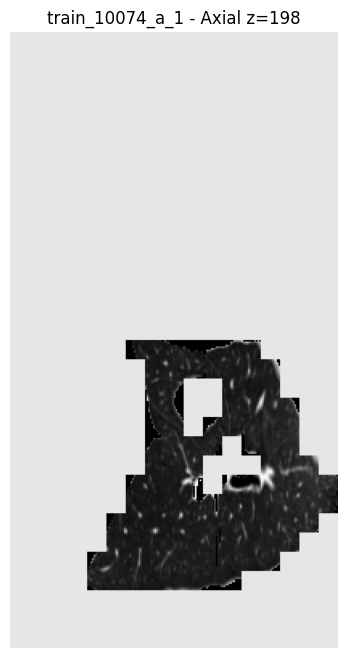

In [5]:
# Axial
z = volume.shape[0] // 2

plt.figure(figsize=(8, 8))
plt.imshow(volume[z], cmap="gray")
plt.title(f"{scan_id} - Axial z={z}")
plt.axis("off")
plt.show()

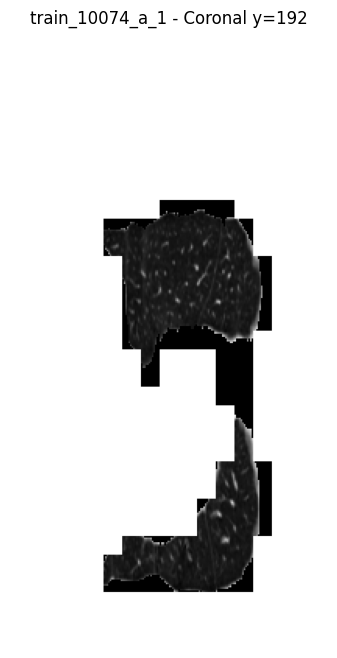

In [6]:
y = volume.shape[1] // 2

plt.figure(figsize=(8, 8))
plt.imshow(volume[:, y, :], cmap="gray")
plt.title(f"{scan_id} - Coronal y={y}")
plt.axis("off")
plt.show()

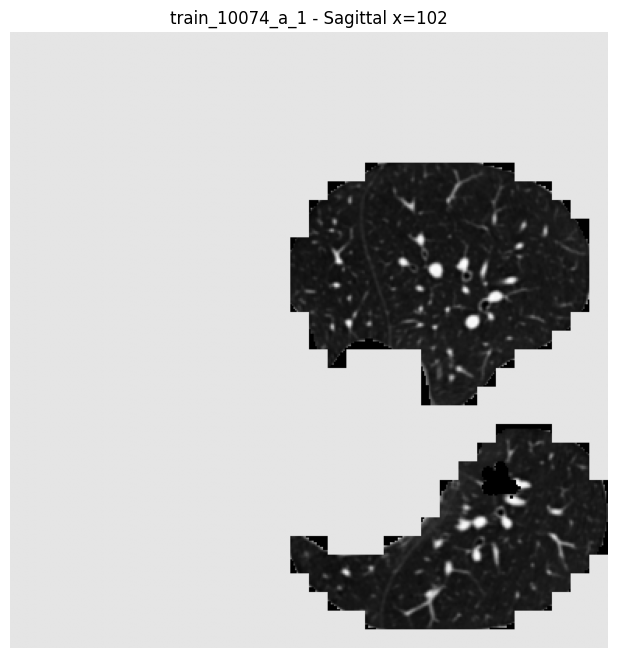

In [7]:
x = volume.shape[2] // 2

plt.figure(figsize=(8, 8))
plt.imshow(volume[:, :, x], cmap="gray")
plt.title(f"{scan_id} - Sagittal x={x}")
plt.axis("off")
plt.show()

Original volume: (396, 384, 204)
Covered voxels: 4553280
3D visualization shape: (99, 96, 51)


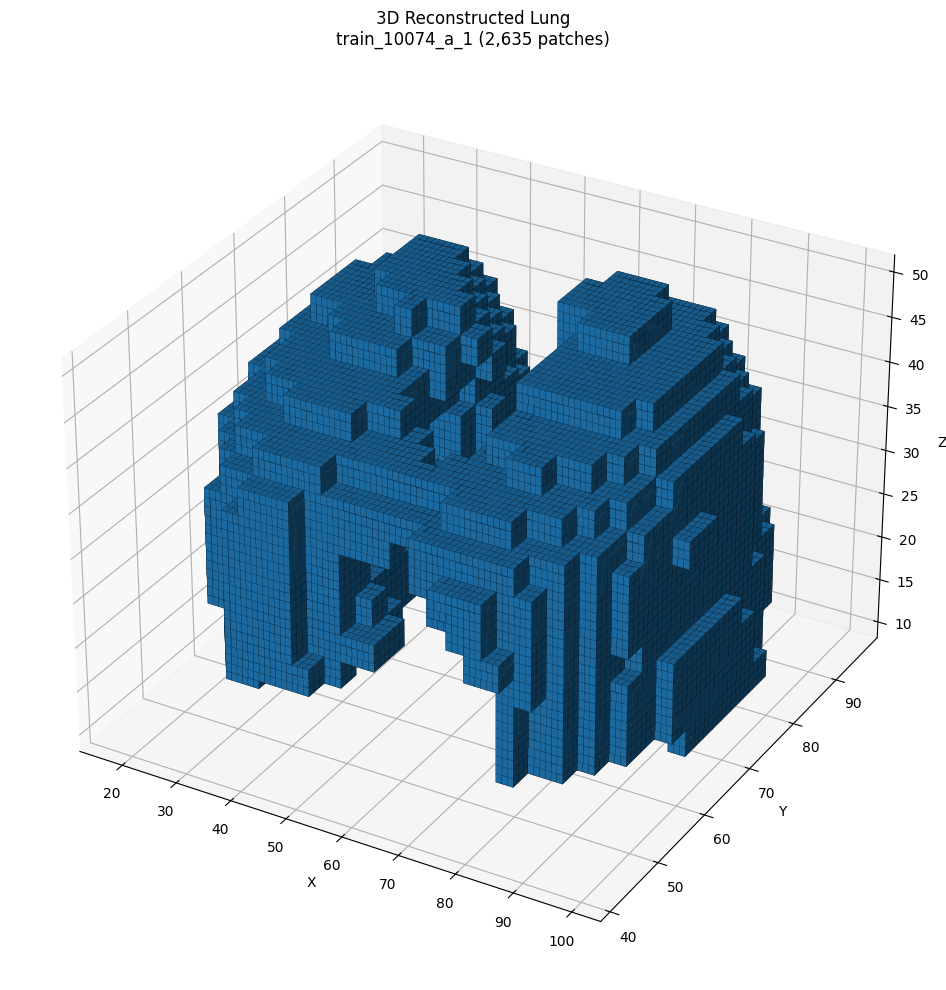

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Create mask of reconstructed voxels
# ---------------------------------------------------------
voxel_mask = volume_count > 0

print("Original volume:", volume.shape)
print("Covered voxels:", voxel_mask.sum())


# ---------------------------------------------------------
# Downsample for visualization
# ---------------------------------------------------------
# Increase this if visualization is slow
DOWNSAMPLE = 4

mask_3d = voxel_mask[
    ::DOWNSAMPLE,
    ::DOWNSAMPLE,
    ::DOWNSAMPLE
]

print("3D visualization shape:", mask_3d.shape)


# ---------------------------------------------------------
# Plot 3D voxels
# ---------------------------------------------------------
fig = plt.figure(figsize=(12, 10))

ax = fig.add_subplot(111, projection="3d")

ax.voxels(
    mask_3d,
    edgecolor="k",
    linewidth=0.1
)

ax.set_title(
    f"3D Reconstructed Lung\n"
    f"{scan_id} ({X_scan.shape[1]:,} patches)"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.tight_layout()
plt.show()